In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out.csv')
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,14
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,14
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,14
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,14
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,14


In [3]:
data=data.sample(frac=1)

data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','C','O','H'],axis=1,inplace=True)
#data= data.set_index('Event')


data= data[data['Gas_Type'] != 'arnco2']
data.drop(['Gas_Type'],axis=1,inplace=True)

data= data[data['Time_Window'] == 3]
data.drop(['Time_Window'],axis=1,inplace=True)



data= data[data['Voltage'] <= 5000]
#data= data[data['Voltage'] >= 3000]

#data.drop(['Voltage'],axis=1,inplace=True)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4049 entries, 20207 to 7968
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               4049 non-null   float64
 1   Ar                4049 non-null   float64
 2   N2                4049 non-null   float64
 3   CO2               4049 non-null   float64
 4   Detector_Area     4049 non-null   float64
 5   Cover_Area        4049 non-null   float64
 6   Cover_Area_Ratio  4049 non-null   float64
 7   Voltage           4049 non-null   int64  
 8   Source            4049 non-null   object 
 9   Peak_Count        4049 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 348.0+ KB


In [5]:
data.isnull()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Peak_Count
20207,False,False,False,False,False,False,False,False,False,False
37917,False,False,False,False,False,False,False,False,False,False
41695,False,False,False,False,False,False,False,False,False,False
14081,False,False,False,False,False,False,False,False,False,False
9119,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
28217,False,False,False,False,False,False,False,False,False,False
29632,False,False,False,False,False,False,False,False,False,False
44515,False,False,False,False,False,False,False,False,False,False
1804,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
Detector_Area       0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Peak_Count          0
dtype: int64

<Axes: >

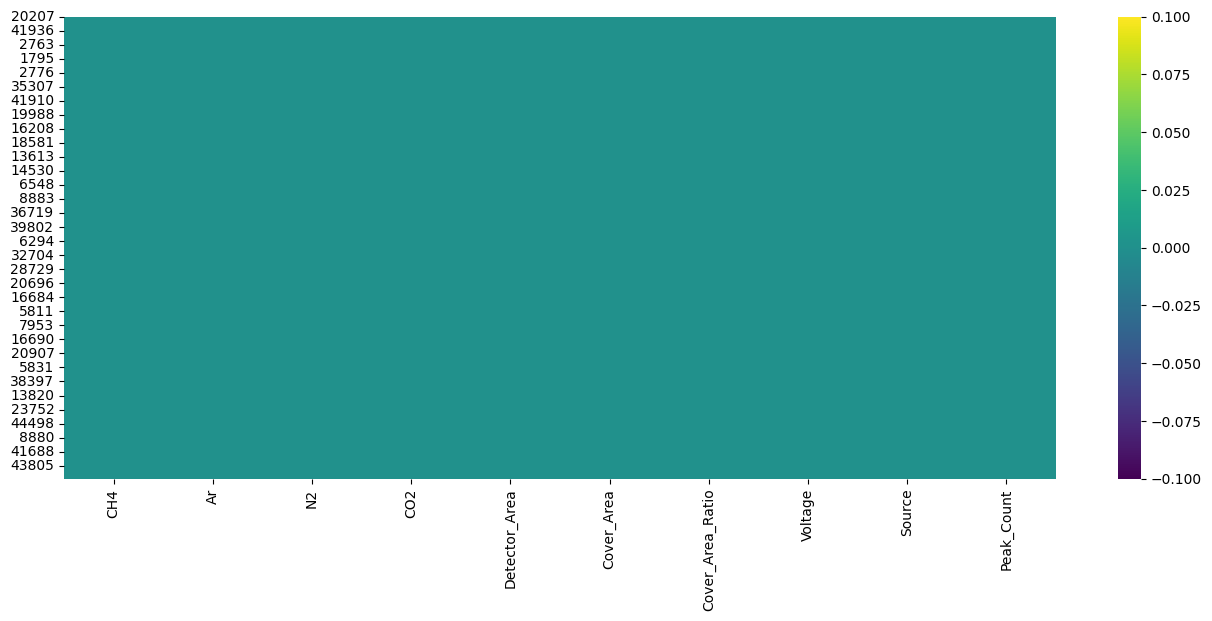

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
Detector_Area       0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Peak_Count          0
dtype: int64

In [10]:
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Peak_Count
20207,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5000,cs,26
37917,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5000,kaynaksız,21
41695,0.2,0.8,0.0,0.0,45.97,22.85,0.50,4500,cs,0
14081,0.1,0.9,0.0,0.0,100.00,64.00,0.64,5000,cs,68
9119,0.1,0.9,0.0,0.0,100.00,16.00,0.16,4000,cs,10


In [11]:
type2=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type2

,kaynaksız
20207,0.0
37917,1.0
41695,0.0
14081,0.0
9119,0.0
...,...
28217,0.0
29632,1.0
44515,0.0
1804,1.0


In [12]:
type=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type

,kaynaksız
20207,0.0
37917,1.0
41695,0.0
14081,0.0
9119,0.0
...,...
28217,0.0
29632,1.0
44515,0.0
1804,1.0


In [13]:
data=pd.concat([data,type2],axis=1)
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Peak_Count,kaynaksız
20207,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5000,cs,26,0.0
37917,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5000,kaynaksız,21,1.0
41695,0.2,0.8,0.0,0.0,45.97,22.85,0.50,4500,cs,0,0.0
14081,0.1,0.9,0.0,0.0,100.00,64.00,0.64,5000,cs,68,0.0
9119,0.1,0.9,0.0,0.0,100.00,16.00,0.16,4000,cs,10,0.0


In [14]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [15]:
data.drop(['Source'],axis=1,inplace=True)
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Peak_Count,kaynaksız
20207,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5000,26,0.0
37917,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5000,21,1.0
41695,0.2,0.8,0.0,0.0,45.97,22.85,0.50,4500,0,0.0
14081,0.1,0.9,0.0,0.0,100.00,64.00,0.64,5000,68,0.0
9119,0.1,0.9,0.0,0.0,100.00,16.00,0.16,4000,10,0.0


In [16]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4049 entries, 20207 to 7968
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               4049 non-null   float64
 1   Ar                4049 non-null   float64
 2   N2                4049 non-null   float64
 3   CO2               4049 non-null   float64
 4   Detector_Area     4049 non-null   float64
 5   Cover_Area        4049 non-null   float64
 6   Cover_Area_Ratio  4049 non-null   float64
 7   Voltage           4049 non-null   int64  
 8   Peak_Count        4049 non-null   int64  
 9   kaynaksız         4049 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 348.0 KB


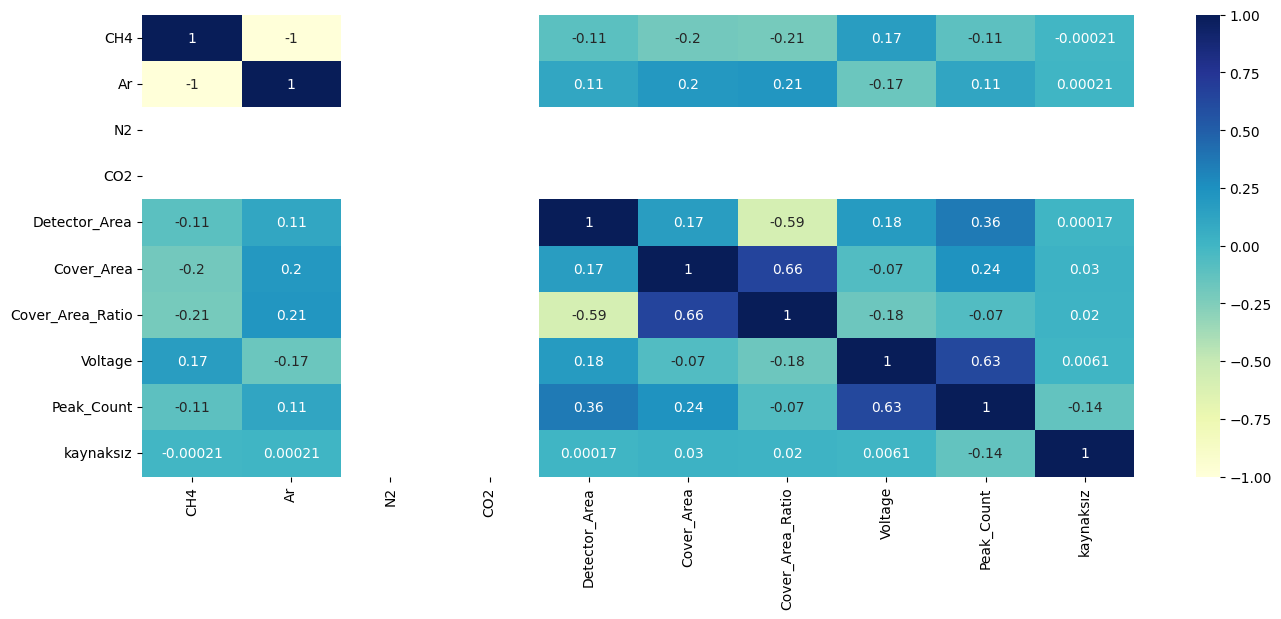

In [17]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [18]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['CH4',
 'Ar',
 'Detector_Area',
 'Cover_Area',
 'Voltage',
 'Peak_Count',
 'kaynaksız']

In [19]:
data=data[list(corr.index)]
data

,CH4,Ar,Detector_Area,Cover_Area,Voltage,Peak_Count,kaynaksız
20207,0.1,0.9,45.97,44.62,5000,26,0.0
37917,0.2,0.8,100.00,64.00,5000,21,1.0
41695,0.2,0.8,45.97,22.85,4500,0,0.0
14081,0.1,0.9,100.00,64.00,5000,68,0.0
9119,0.1,0.9,100.00,16.00,4000,10,0.0
...,...,...,...,...,...,...,...
28217,0.2,0.8,100.00,36.00,3500,0,0.0
29632,0.2,0.8,100.00,36.00,3500,0,1.0
44515,0.2,0.8,45.97,22.85,3000,0,0.0
1804,0.1,0.9,100.00,36.00,5000,18,1.0


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,Detector_Area,Cover_Area,Voltage,kaynaksız
20207,0.1,0.9,45.97,44.62,5000,0.0
37917,0.2,0.8,100.00,64.00,5000,1.0
41695,0.2,0.8,45.97,22.85,4500,0.0
14081,0.1,0.9,100.00,64.00,5000,0.0
9119,0.1,0.9,100.00,16.00,4000,0.0


In [22]:
y=data['Peak_Count']
y

20207    26
37917    21
41695     0
14081    68
9119     10
         ..
28217     0
29632     0
44515     0
1804     18
7968     21
Name: Peak_Count, Length: 4049, dtype: int64

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,y_train)

In [ ]:
pred=model.predict(X_test)
pred

In [ ]:
y_test

In [ ]:
X_test

In [ ]:
model.score(X_test, y_test)

In [ ]:
pred

In [ ]:
y_test

In [ ]:
indexes = X_test.index.values
len(indexes)

In [ ]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()